# Hyperparameter Tuning with Optuna

This notebook is a practical walkthrough of Optuna for machine learning model tuning.

## Contents
- Optuna fundamentals and terminology
- Random Forest tuning on an imbalanced dataset
- Sampler comparison (TPE, Random, Grid)
- Optuna visualization tools
- Optuna + XGBoost pipeline example

## Outcome
You will understand how to define objective functions, search spaces, and evaluate tuned models with reliable metrics.

In [47]:
!pip install optuna

In [48]:
import optuna
print(optuna.__version__)

4.8.0


[OptunaPaper](https://arxiv.org/pdf/1907.10902)

## Optuna (Hyperparameter Tuning Tool)

**Definition:**  
Optuna is an automatic hyperparameter optimization framework used to efficiently tune machine learning models.

---

## Key

- Instead of manually trying different hyperparameters  
- Optuna **automatically searches for the best combination**  
- Uses intelligent strategies (not brute force)

---

## Why Use Optuna?

- Works well on **complex datasets and models**  
- More efficient than:
  - Grid Search  
  - Random Search  
- Finds better results with fewer trials  

---

## How It Works

1. Define an **objective function** (model + evaluation metric)  
2. Optuna suggests hyperparameters  
3. Model is trained and evaluated  
4. Process repeats for multiple trials  
5. Best parameters are selected  

---

## Example Use Cases

- XGBoost tuning  
- Neural network tuning  
- Any ML model with multiple hyperparameters  

---

## Advantages

- Fast and efficient  
- Easy to use  
- Supports pruning (early stopping of bad trials)  
- Works with most ML libraries  

---



Optuna automates hyperparameter tuning by **learning from previous trials**,  
making it smarter than traditional search methods.

---
---

## Why Learn Optuna?

When a model has many hyperparameters (for example, Random Forest), manual tuning is slow and inefficient.

Grid Search checks every combination from a fixed grid, which quickly becomes expensive as parameters increase.

Optuna improves this process by:
- Searching hyperparameters intelligently instead of brute force
- Learning from previous trials to focus on promising regions
- Finding strong configurations with fewer experiments

In short, Optuna helps you reach better model performance with less computation.

---
---

## Bayesian Search Idea
> [Read_BayesianSearchPaper](https://arxiv.org/pdf/2304.11127)

There is a relationship between hyperparameters and model performance:

$$
\text{accuracy} = f(\text{max\_depth}, \text{n\_estimators})
$$

This means:
- Changing hyperparameters changes accuracy  
- There exists an underlying function (graph) connecting them  

---

## Key Idea

- Bayesian search tries to **learn this function**  
- It models how hyperparameters affect accuracy  
- It builds an approximate graph of this relationship  

---

## Process

1. Try some initial combinations  
   - Example:
     - max_depth = 5, n_estimators = 100 → accuracy = 75  
     - max_depth = 10, n_estimators = 150 → accuracy = 69  

2. Observe results and **learn patterns**  

3. Build an approximation of:
   $$
   f(\text{max\_depth}, \text{n\_estimators})
   $$

4. Use this learned function to:
   - Explore promising regions  
   - Avoid poor regions  

---

## Goal

- Find the **maximum (maxima)** of the function  

$$
\max f(\text{max\_depth}, \text{n\_estimators})
$$

- This gives:
  - Best accuracy  
  - Corresponding best hyperparameters  

---

## Insight

Bayesian search does not try all combinations.  
It **learns the shape of the function** and intelligently moves toward the maximum.

---
---

## Key Terms Before Using Optuna

Before diving into Optuna for hyperparameter tuning, it is important to understand the core terminology used within the framework. These concepts form the foundation of how Optuna operates.

---

## 1. Study

A **study** represents the entire optimization process.  
It is a collection of multiple trials aimed at finding the best set of hyperparameters for a given objective function.

You can think of a study as the **overall experiment**.

**Example:**  
A study that searches for the optimal hyperparameters of an XGBoost model.

---

## 2. Trial

A **trial** is a single iteration within a study.  
In each trial, a specific combination of hyperparameters is selected and evaluated by running the objective function.

Each trial is independent and explores a different point in the search space.

**Example:**  
Training a model with:
- learning rate = 0.01  
- max depth = 5  

---

## 3. Trial Parameters

**Trial parameters** are the specific hyperparameter values used in a single trial.  
Each trial has a unique set of parameters, allowing the model to explore different configurations.

**Example:**  
- Trial 1 → learning rate = 0.001, batch size = 32  
- Trial 2 → learning rate = 0.01, batch size = 64  

---

## 4. Objective Function

The **objective function** defines what you want to optimize.  
It takes hyperparameters as input and returns a performance metric such as accuracy, loss, or F1-score.

Optuna tries to either **minimize or maximize** this value depending on the problem.

**Example:**  
In classification, minimizing **cross-entropy loss** or maximizing **accuracy**.

---

## 5. Sampler

A **sampler** determines how new hyperparameter values are selected for each trial.  
It guides the search process by deciding which regions of the search space to explore.

By default, Optuna uses the **Tree-structured Parzen Estimator (TPE)**, a Bayesian optimization method that focuses on promising regions.

**Example:**  
TPE prioritizes hyperparameter combinations that are more likely to produce better results based on previous trials.

---
## 
Optuna works by combining:
- **Trials** → exploring different configurations  
- **Objective Function** → evaluating performance  
- **Sampler** → guiding the search intelligently  

Together, these components enable efficient and effective hyperparameter optimization.

---
---

## Code 
> Using diabetes dataset 

In [49]:
import optuna
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [50]:
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"

columns = [
    'Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
    'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'
]

df = pd.read_csv(url, names=columns)

print("Shape:", df.shape)
print("\nFirst 5 rows:")
display(df.head())

print("\nClass Distribution:")
print(df['Outcome'].value_counts())

Shape: (768, 9)

First 5 rows:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1



Class Distribution:
Outcome
0    500
1    268
Name: count, dtype: int64


##### treating null value 

In [51]:
import numpy as np

# Replace zero values with NaN in columns where zero is not a valid value
cols_with_missing_vals = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
df[cols_with_missing_vals] = df[cols_with_missing_vals].replace(0, np.nan)

# Impute the missing values with the median of the respective column
df.fillna(df.median(), inplace=True)

# Check ? are any remaining missing values
print(df.isnull().sum())

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [52]:
X = df.drop('Outcome', axis=1)
y = df['Outcome']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# optional here as we are using random forest
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

X_train.shape , X_test.shape

((537, 8), (231, 8))

In [53]:
import optuna
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import roc_auc_score

In [54]:
def objective(trial):
    
    # hyperparameter search space
    n_estimators = trial.suggest_int("n_estimators", 50, 300)
    max_depth = trial.suggest_int("max_depth", 2, 20)
    min_samples_split = trial.suggest_int("min_samples_split", 2, 10)
    min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 5)
    
    # model
    model = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        class_weight='balanced',   # important for imbalance
        random_state=42,
        n_jobs=-1
    )
    
    # Cross-validation 
    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=5,
        scoring="roc_auc"
    )
    
    return scores.mean()

# create study 
study = optuna.create_study(direction="maximize")

# run optimization
study.optimize(objective, n_trials=30)

# best result 

print("Best Trial:")
print("Value (ROC AUC):", study.best_trial.value)
print("Best Params:", study.best_trial.params)

[I 2026-04-25 02:28:35,733] A new study created in memory with name: no-name-063a9ff9-e66f-4269-9cfd-da58cdef091a
[I 2026-04-25 02:28:36,407] Trial 0 finished with value: 0.846322445361347 and parameters: {'n_estimators': 61, 'max_depth': 16, 'min_samples_split': 9, 'min_samples_leaf': 4}. Best is trial 0 with value: 0.846322445361347.
[I 2026-04-25 02:28:37,299] Trial 1 finished with value: 0.8435437300654692 and parameters: {'n_estimators': 85, 'max_depth': 15, 'min_samples_split': 5, 'min_samples_leaf': 2}. Best is trial 0 with value: 0.846322445361347.
[I 2026-04-25 02:28:38,590] Trial 2 finished with value: 0.8443624042479879 and parameters: {'n_estimators': 123, 'max_depth': 9, 'min_samples_split': 6, 'min_samples_leaf': 1}. Best is trial 0 with value: 0.846322445361347.
[I 2026-04-25 02:28:39,314] Trial 3 finished with value: 0.8466241691184482 and parameters: {'n_estimators': 61, 'max_depth': 13, 'min_samples_split': 4, 'min_samples_leaf': 3}. Best is trial 3 with value: 0.8466

Best Trial:
Value (ROC AUC): 0.8556315288809568
Best Params: {'n_estimators': 235, 'max_depth': 7, 'min_samples_split': 10, 'min_samples_leaf': 4}


**Best parameters found (example run):**

- `n_estimators`: 235
- `max_depth`: 7
- `min_samples_split`: 10
- `min_samples_leaf`: 4

In [55]:
best_model = RandomForestClassifier(
    **study.best_trial.params,
    class_weight='balanced',
    random_state=42
)

In [56]:
best_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",235
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",7
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",10
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",4
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

In [57]:
from sklearn.metrics import classification_report, roc_auc_score

y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

print("Classification Report:\n")
print(classification_report(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_proba))

Classification Report:

              precision    recall  f1-score   support

           0       0.85      0.72      0.78       151
           1       0.59      0.76      0.66        80

    accuracy                           0.73       231
   macro avg       0.72      0.74      0.72       231
weighted avg       0.76      0.73      0.74       231

ROC AUC: 0.815066225165563


##  Questions and Answers

##### 1. What is the objective function in Optuna and what role does it play?
The objective function defines what we want to optimize. It takes hyperparameters as input, trains the model, evaluates it, and returns a score. Optuna uses this score to guide the search.

##### 2. What is a trial in Optuna?
A trial is one iteration of the optimization process where a specific set of hyperparameters is evaluated.

##### 3. What does `trial.suggest_int()` do?
It defines a range for an integer hyperparameter and lets Optuna choose values from that range during optimization.

##### 4. Why do we define a search space for hyperparameters?
To limit and guide the optimization process. Without a search space, the algorithm cannot explore meaningful parameter values.

##### 5. Why do we use cross-validation instead of a single train-test split?
Cross-validation provides a more reliable estimate of model performance by reducing variance and avoiding overfitting to a single split.

##### 6. Why is `scoring="roc_auc"` used in this problem?
ROC-AUC measures how well the model distinguishes between classes and is more suitable for imbalanced datasets.

##### 7. Why is accuracy not a reliable metric for imbalanced datasets?
Because a model can achieve high accuracy by predicting only the majority class while failing on the minority class.

##### 8. Why do we use `class_weight='balanced'` in Random Forest?
To assign higher importance to the minority class, helping the model learn from imbalanced data.

##### 9. What does `optuna.create_study(direction="maximize")` mean?
It creates an optimization study and indicates that the objective function should be maximized.

##### 10. What happens internally when we call `study.optimize(objective, n_trials=30)`?
Optuna runs the objective function 30 times with different hyperparameters and uses previous results to improve future trials.

##### 11. What is stored inside `study.best_trial`?
The best-performing trial, including the highest score and corresponding hyperparameters.

##### 12. Why do we retrain the model using the best hyperparameters after tuning?
Because cross-validation only evaluates performance. Retraining builds the final model using optimal parameters.

##### 13. Why do we use `predict_proba()` instead of `predict()` for ROC-AUC?
ROC-AUC requires probability scores, not discrete class labels.

##### 14. Why is scaling optional for Random Forest?
Random Forest is a tree-based model and does not rely on feature scaling.

##### 15. What is the difference between Grid Search, Random Search, and Optuna?
Grid Search tries all combinations, Random Search samples randomly, and Optuna uses Bayesian optimization to search intelligently.

##### 16. What is TPE (Tree-structured Parzen Estimator) in Optuna?
It is a Bayesian optimization method that models the performance of hyperparameters and focuses on promising regions.

##### 17. Why do we use `n_jobs=-1` in Random Forest?
To utilize all CPU cores for parallel processing and speed up training.

##### 18. What is overfitting and how is it controlled in this model?
Overfitting occurs when a model learns noise instead of patterns. It is controlled using hyperparameters like max_depth and min_samples_leaf and by using cross-validation.

##### 19. Why is `min_samples_leaf` an important hyperparameter?
It prevents very small leaf nodes, reducing noise and improving generalization.

##### 20. Why do we split the dataset into training and testing sets?
To evaluate model performance on unseen data and ensure generalization.

##### 21. Why is data cleaning necessary before training?
To remove invalid or missing values that can negatively affect model performance.

##### 22. What is the impact of imbalanced data on model performance?
It can bias the model toward the majority class and reduce performance on the minority class.

##### 23. Why do we use ROC-AUC instead of accuracy for evaluation?
ROC-AUC evaluates model performance across thresholds and is more robust for imbalanced data.

##### 24. What happens if we do not use cross-validation during tuning?
The model may overfit to a specific train-test split, leading to unreliable results.

##### 25. Why is hyperparameter tuning important in machine learning?
It helps find the optimal configuration for a model, improving performance and generalization.

##### 26. What is the advantage of Bayesian optimization over traditional methods?
It uses past results to guide the search, making it more efficient than exhaustive or random methods.

##### 27. How does Optuna decide the next set of hyperparameters to try?
It uses the TPE sampler to model past trials and select promising hyperparameter values.

##### 28. Why is reproducibility important and how can it be achieved in Optuna?
Reproducibility ensures consistent results. It can be achieved by setting random seeds in both the model and sampler.

##### 29. What is the difference between training performance and test performance?
Training performance measures how well the model fits training data, while test performance evaluates generalization on unseen data.

##### 30. What is the complete machine learning pipeline followed in this code?
Data loading, data cleaning, train-test split, feature scaling, hyperparameter tuning using Optuna, model training, and evaluation.

###

## 

Optuna is not limited to a single sampling strategy.  
It allows you to use different samplers such as Random Search and Grid Search.

---

## key idea

- You only need to define the **objective function**  
- The sampling strategy can be changed using the `sampler` argument in `create_study()`  

---

## Random Sampler

You can perform Random Search using `RandomSampler`.

```python
study = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.RandomSampler()
)

study.optimize(objective, n_trials=30)

In [58]:
import optuna

# random sampler 

random_study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.RandomSampler(seed=42)
)

random_study.optimize(objective, n_trials=30)

print("Random Sampler Best:")
print(random_study.best_trial.value)
print(random_study.best_trial.params)


# grid sampler

search_space = {
    "n_estimators": [50, 100, 200],
    "max_depth": [3, 5, 7],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 3]
}

grid_sampler = optuna.samplers.GridSampler(search_space)

grid_study = optuna.create_study(
    direction="maximize",
    sampler=grid_sampler
)

grid_study.optimize(objective)

print("\nGrid Sampler Best:")
print(grid_study.best_trial.value)
print(grid_study.best_trial.params)

[I 2026-04-25 02:29:54,770] A new study created in memory with name: no-name-4e60fe60-416a-4bb4-a1fc-29ccacfd6d23
[I 2026-04-25 02:29:56,102] Trial 0 finished with value: 0.8527909373904798 and parameters: {'n_estimators': 144, 'max_depth': 20, 'min_samples_split': 8, 'min_samples_leaf': 3}. Best is trial 0 with value: 0.8527909373904798.
[I 2026-04-25 02:29:57,026] Trial 1 finished with value: 0.8516464781224509 and parameters: {'n_estimators': 89, 'max_depth': 4, 'min_samples_split': 2, 'min_samples_leaf': 5}. Best is trial 0 with value: 0.8527909373904798.
[I 2026-04-25 02:29:58,853] Trial 2 finished with value: 0.8510433840182123 and parameters: {'n_estimators': 200, 'max_depth': 15, 'min_samples_split': 2, 'min_samples_leaf': 5}. Best is trial 0 with value: 0.8527909373904798.
[I 2026-04-25 02:30:01,427] Trial 3 finished with value: 0.8514797864225783 and parameters: {'n_estimators': 258, 'max_depth': 6, 'min_samples_split': 3, 'min_samples_leaf': 1}. Best is trial 0 with value: 0

Random Sampler Best:
0.8549053597566184
{'n_estimators': 240, 'max_depth': 12, 'min_samples_split': 8, 'min_samples_leaf': 3}


[I 2026-04-25 02:30:42,134] A new study created in memory with name: no-name-6e58bd25-a360-446e-8556-0a86080cd7ad
[I 2026-04-25 02:30:42,994] Trial 0 finished with value: 0.8528251887061955 and parameters: {'n_estimators': 100, 'max_depth': 7, 'min_samples_split': 2, 'min_samples_leaf': 3}. Best is trial 0 with value: 0.8528251887061955.
[I 2026-04-25 02:30:44,551] Trial 1 finished with value: 0.8554868958530287 and parameters: {'n_estimators': 200, 'max_depth': 5, 'min_samples_split': 2, 'min_samples_leaf': 3}. Best is trial 1 with value: 0.8554868958530287.
[I 2026-04-25 02:30:45,429] Trial 2 finished with value: 0.8528161767521034 and parameters: {'n_estimators': 100, 'max_depth': 5, 'min_samples_split': 5, 'min_samples_leaf': 1}. Best is trial 1 with value: 0.8554868958530287.
[I 2026-04-25 02:30:45,922] Trial 3 finished with value: 0.8562310888855512 and parameters: {'n_estimators': 50, 'max_depth': 7, 'min_samples_split': 2, 'min_samples_leaf': 3}. Best is trial 3 with value: 0.8


Grid Sampler Best:
0.8562310888855512
{'n_estimators': 50, 'max_depth': 7, 'min_samples_split': 2, 'min_samples_leaf': 3}


**Sampler comparison (example run):**

- Random Sampler best ROC-AUC: `0.8549`
- Random Sampler best params: `n_estimators=240, max_depth=12, min_samples_split=8, min_samples_leaf=3`
- Grid Sampler best ROC-AUC: `0.8562`
- Grid Sampler best params: `n_estimators=50, max_depth=7, min_samples_split=2, min_samples_leaf=3`

| Sampler           | ROC AUC           | Best Params                                             |
| ----------------- | ----------------- | ------------------------------------------------------- |
| **TPE (default)** | **0.81**        | n_estimators=300, max_depth=7, min_split=2, min_leaf=4  |
| **Random**        | 0.8549            | n_estimators=240, max_depth=12, min_split=8, min_leaf=3 |
| **Grid**          | **0.8562 (best)** | n_estimators=50, max_depth=7, min_split=2, min_leaf=3   |


> Optuna gives us flexibility to use different samplers depending on the search strategy we want.

## Visualization in Optuna

In [60]:
from optuna.visualization import (
    plot_optimization_history,
    plot_param_importances,
    plot_parallel_coordinate,
    plot_slice,
    plot_contour
)

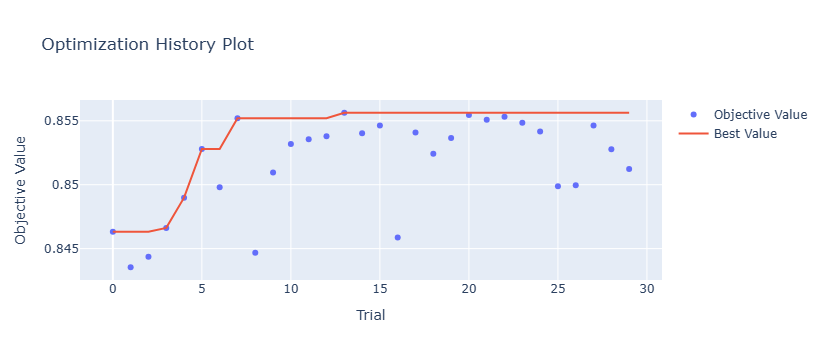

In [61]:
plot_optimization_history(study)

### Optimization History Plot

What it shows:
- Trial number versus objective score (ROC-AUC)

What to look for:
- Whether performance improves over time
- Whether optimization converges early

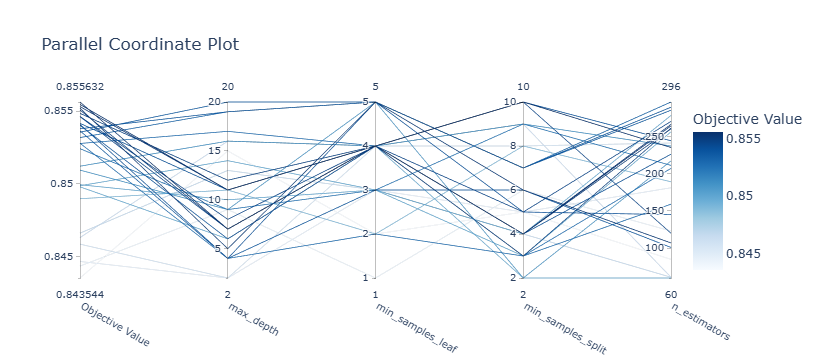

In [62]:
plot_parallel_coordinate(study)

### Parallel Coordinate Plot

What it shows:
- Relationship between multiple hyperparameters and performance

What to look for:
- Parameter combinations associated with high scores
- Cross-parameter patterns across trials

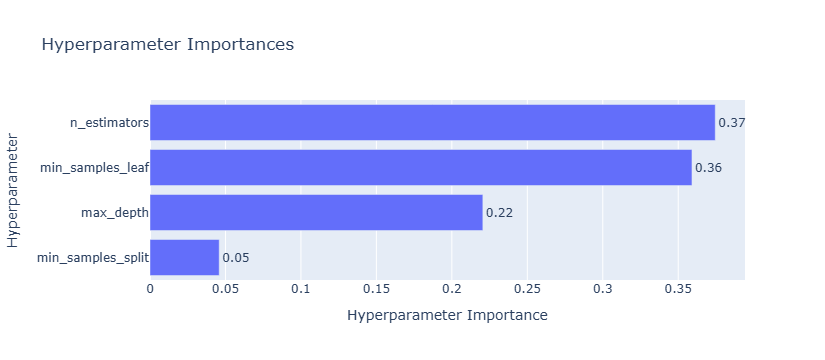

In [63]:
plot_param_importances(study)

### Hyperparameter Importance Plot

What it shows:
- Which hyperparameters influence performance the most

How to use it:
- Prioritize tuning of high-importance parameters
- Spend less effort on low-impact parameters

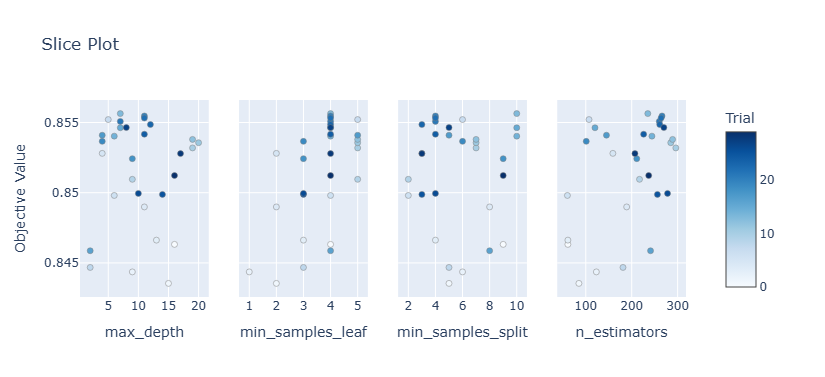

In [64]:
plot_slice(study)

### Slice Plot

What it shows:
- Individual hyperparameter values versus objective score

What to look for:
- Promising value ranges for each parameter

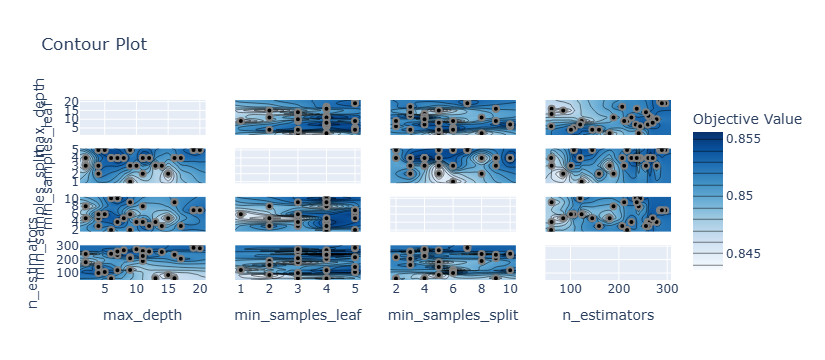

In [65]:
plot_contour(study)

### Contour Plot

What it shows:
- Interaction effects between two hyperparameters

What to look for:
- Parameter pairs that jointly improve performance

## Favorite Feature in Optuna

## Optuna Define-by-Run: Dynamic Search Spaces

Optuna follows a **define-by-run** approach, which allows you to create **dynamic and flexible search spaces** during runtime.

---

## Key Idea

Instead of fixing the search space beforehand, Optuna allows you to:

- Dynamically define hyperparameters  
- Change the search space based on conditions  
- Even choose different algorithms during optimization  

---

## Problem

When working with machine learning:

- You first choose an algorithm (e.g., Random Forest, SVM, XGBoost)  
- Then you perform hyperparameter tuning for that algorithm  

This process is repetitive because:
- Each algorithm has its own hyperparameters  
- You need to tune each model separately  

---

## Solution: Treat Algorithm as a Hyperparameter

Optuna allows you to:

- Include the **algorithm choice itself as a parameter**  
- Try multiple algorithms within a single optimization process  
- Automatically find:
  - Best algorithm  
  - Best hyperparameters  

---

## How It Works

1. Select an algorithm using `trial.suggest_categorical()`
2. Based on the selected algorithm, define a **different search space**
3. Train and evaluate the chosen model
4. Return the performance score

---

## Example Logic

```python
model_type = trial.suggest_categorical("model", ["rf", "svm", "xgb"])

if model_type == "rf":
    # Random Forest search space
elif model_type == "svm":
    # SVM search space
elif model_type == "xgb":
    # XGBoost search space

# code 

In [66]:
import optuna
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_score

In [70]:
def objective(trial):

    model_type = trial.suggest_categorical("model", ["rf", "svm", "xgb"])

    # random forest 
    if model_type == "rf":
        n_estimators = trial.suggest_int("rf_n_estimators", 50, 300)
        max_depth = trial.suggest_int("rf_max_depth", 2, 20)

        model = RandomForestClassifier(
            n_estimators=n_estimators,
            max_depth=max_depth,
            class_weight='balanced',
            random_state=42,
            n_jobs=-1
        )

    # SVM
    elif model_type == "svm":
        C = trial.suggest_float("svm_C", 0.01, 10, log=True)
        kernel = trial.suggest_categorical("svm_kernel", ["linear", "rbf"])

        model = SVC(
            C=C,
            kernel=kernel,
            probability=True
        )

    # XGBoost
    else:
        n_estimators = trial.suggest_int("xgb_n_estimators", 50, 300)
        max_depth = trial.suggest_int("xgb_max_depth", 3, 10)
        learning_rate = trial.suggest_float("xgb_lr", 0.01, 0.3)

        model = XGBClassifier(
            n_estimators=n_estimators,
            max_depth=max_depth,
            learning_rate=learning_rate,
            eval_metric="logloss",random_state=42)

    # Evaluation
    score = cross_val_score(
        model,
        X_train,
        y_train,
        cv=5,
        scoring="roc_auc"
    ).mean()

    return score

In [71]:
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=100)

[I 2026-04-25 02:35:56,871] A new study created in memory with name: no-name-c5de009c-cd7d-4630-8bba-f9e84a2699a6
[I 2026-04-25 02:35:57,269] Trial 0 finished with value: 0.8114433851962456 and parameters: {'model': 'xgb', 'xgb_n_estimators': 261, 'xgb_max_depth': 10, 'xgb_lr': 0.23095690339553637}. Best is trial 0 with value: 0.8114433851962456.
[I 2026-04-25 02:35:57,565] Trial 1 finished with value: 0.8362096192302143 and parameters: {'model': 'xgb', 'xgb_n_estimators': 185, 'xgb_max_depth': 5, 'xgb_lr': 0.03345745682404648}. Best is trial 1 with value: 0.8362096192302143.
[I 2026-04-25 02:35:57,774] Trial 2 finished with value: 0.8130940453366083 and parameters: {'model': 'xgb', 'xgb_n_estimators': 229, 'xgb_max_depth': 3, 'xgb_lr': 0.19098263868104495}. Best is trial 1 with value: 0.8362096192302143.
[I 2026-04-25 02:35:58,124] Trial 3 finished with value: 0.8058555024458915 and parameters: {'model': 'xgb', 'xgb_n_estimators': 283, 'xgb_max_depth': 5, 'xgb_lr': 0.21173800671946524

In [72]:
print("Best Score:", study.best_value)
print("Best Params:", study.best_params)

Best Score: 0.8552452812407045
Best Params: {'model': 'rf', 'rf_n_estimators': 197, 'rf_max_depth': 4}


In [74]:
# you can also print all the trials in a dataframe

study.trials_dataframe()

,number,value,datetime_start,datetime_complete,duration,params_model,params_rf_max_depth,params_rf_n_estimators,params_svm_C,params_svm_kernel,params_xgb_lr,params_xgb_max_depth,params_xgb_n_estimators,state
0,0,0.811443,2026-04-25 02:35:56.873205,2026-04-25 02:35:57.269007,0 days 00:00:00.395802,xgb,NaN,NaN,NaN,NaN,0.230957,10.0,261.0,COMPLETE
1,1,0.836210,2026-04-25 02:35:57.270007,2026-04-25 02:35:57.565466,0 days 00:00:00.295459,xgb,NaN,NaN,NaN,NaN,0.033457,5.0,185.0,COMPLETE
2,2,0.813094,2026-04-25 02:35:57.565466,2026-04-25 02:35:57.774895,0 days 00:00:00.209429,xgb,NaN,NaN,NaN,NaN,0.190983,3.0,229.0,COMPLETE
3,3,0.805856,2026-04-25 02:35:57.775894,2026-04-25 02:35:58.124385,0 days 00:00:00.348491,xgb,NaN,NaN,NaN,NaN,0.211738,5.0,283.0,COMPLETE
4,4,0.849333,2026-04-25 02:35:58.125384,2026-04-25 02:35:58.263615,0 days 00:00:00.138231,svm,NaN,NaN,0.867398,linear,NaN,NaN,NaN,COMPLETE
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,95,0.854640,2026-04-25 02:37:59.487401,2026-04-25 02:38:01.290714,0 days 00:00:01.803313,rf,4.0,196.0,NaN,NaN,NaN,NaN,NaN,COMPLETE
96,96,0.845503,2026-04-25 02:38:01.292147,2026-04-25 02:38:03.279009,0 days 00:00:01.986862,rf,2.0,225.0,NaN,NaN,NaN,NaN,NaN,COMPLETE
97,97,0.854486,2026-04-25 02:38:03.279009,2026-04-25 02:38:04.999655,0 days 00:00:01.720646,rf,4.0,195.0,NaN,NaN,NaN,NaN,NaN,COMPLETE
98,98,0.850416,2026-04-25 02:38:05.000647,2026-04-25 02:38:06.765537,0 days 00:00:01.764890,rf,6.0,197.0,NaN,NaN,NaN,NaN,NaN,COMPLETE


In [76]:
study.trials_dataframe()['params_model'].value_counts()

params_model
rf     74
svm    14
xgb    12
Name: count, dtype: int64

In [ ]:
study.trials_dataframe().groupby('params_model')['value'].mean()

params_model
rf     0.850334
svm    0.846139
xgb    0.816841
Name: value, dtype: float64

In [78]:
df = study.trials_dataframe()

print("Count:")
print(df['params_model'].value_counts())

print("\nMean Score:")
# avg performance per mode
print(df.groupby('params_model')['value'].mean())

print("\nBest Score:")
print(df.groupby('params_model')['value'].max())

Count:
params_model
rf     74
svm    14
xgb    12
Name: count, dtype: int64

Mean Score:
params_model
rf     0.850334
svm    0.846139
xgb    0.816841
Name: value, dtype: float64

Best Score:
params_model
rf     0.855245
svm    0.849493
xgb    0.839720
Name: value, dtype: float64


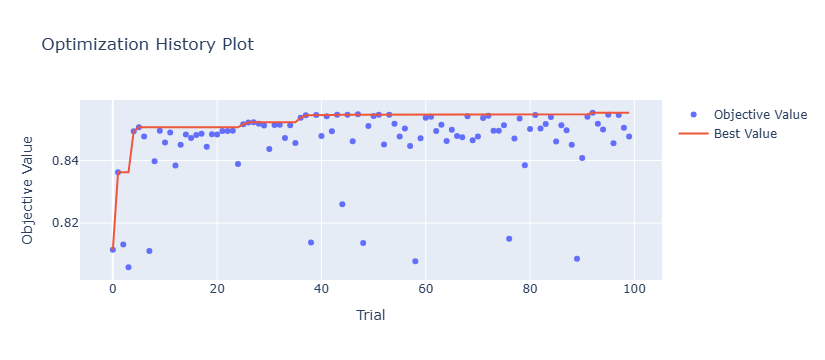

In [79]:
# 1. Optimization History
plot_optimization_history(study).show()

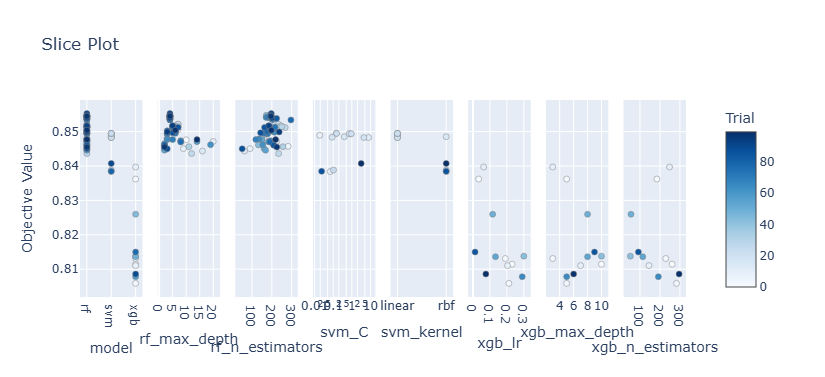

In [80]:
# 3. Slice Plot
plot_slice(study).show()

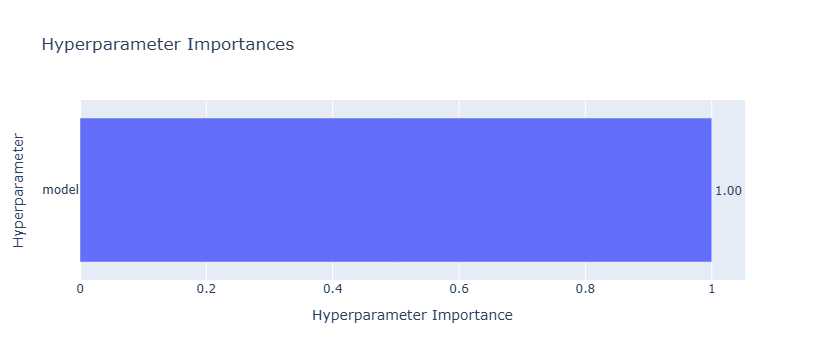

In [81]:
# 5. Hyperparameter Importance
plot_param_importances(study).show()

## Additional Optuna Strengths

- Supports distributed optimization for faster large-scale searches
- Integrates well with libraries such as scikit-learn, Keras, PyTorch, and MLflow
- Works effectively for both classical ML and deep learning workflows

## Optuna + XGBoost pipeline

In [83]:
! pip install optuna-integration[xgboost]

In [84]:
import optuna
import xgboost as xgb
import numpy as np

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score


# load data 

X, y = load_iris(return_X_y=True)

# Train / Validation / Test split 
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train, X_valid, y_train, y_valid = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp
)
# final spli t: 60 : 20: 20 


def objective(trial):

    params = {
        "objective": "multi:softprob",
        "num_class": 3,
        "eval_metric": "mlogloss",
        "booster": "gbtree",
        "verbosity": 0,

        # Regularization
        "lambda": trial.suggest_float("lambda", 1e-8, 10.0, log=True),
        "alpha": trial.suggest_float("alpha", 1e-8, 10.0, log=True),

        # Tree parameters
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "gamma": trial.suggest_float("gamma", 1e-8, 1.0, log=True),

        # Sampling
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),

        # Learning
        "eta": trial.suggest_float("eta", 0.01, 0.3),
    }

    # convert to DMatrix
    
    dtrain = xgb.DMatrix(X_train, label=y_train)
    dvalid = xgb.DMatrix(X_valid, label=y_valid)

    # pruning callback (uses validation set)
    pruning_callback = optuna.integration.XGBoostPruningCallback(
        trial, "validation-mlogloss"
    )

    # train
    model = xgb.train(
        params,
        dtrain,
        num_boost_round=300,
        evals=[(dvalid, "validation")],  # NO test leakage
        early_stopping_rounds=30,
        callbacks=[pruning_callback],
    )

    # predict on validation set
    preds = model.predict(dvalid)
    y_pred = np.argmax(preds, axis=1)

    return accuracy_score(y_valid, y_pred)


# create study
study = optuna.create_study(
    direction="maximize",
    pruner=optuna.pruners.SuccessiveHalvingPruner()
)

study.optimize(objective, n_trials=50)


# train final model on best parametrs

best_params = study.best_params

final_params = {
    **best_params,
    "objective": "multi:softprob",
    "num_class": 3,
    "eval_metric": "mlogloss",
    "verbosity": 0,
}

dtrain_full = xgb.DMatrix(X_temp, label=y_temp)
dtest = xgb.DMatrix(X_test, label=y_test)

final_model = xgb.train(
    final_params,
    dtrain_full,
    num_boost_round=study.best_trial.number + 50
)

# final evaluation 
preds = final_model.predict(dtest)
y_pred = np.argmax(preds, axis=1)

print("Best Params:", study.best_params)
print("Best Validation Accuracy:", study.best_value)
print("Test Accuracy:", accuracy_score(y_test, y_pred))

[I 2026-04-25 02:49:33,065] A new study created in memory with name: no-name-da9727f9-e2b6-40dd-b456-95dcef526092


[0]	validation-mlogloss:0.89055
[1]	validation-mlogloss:0.74211
[2]	validation-mlogloss:0.63642
[3]	validation-mlogloss:0.54716
[4]	validation-mlogloss:0.48258
[5]	validation-mlogloss:0.43758
[6]	validation-mlogloss:0.39822
[7]	validation-mlogloss:0.36149
[8]	validation-mlogloss:0.34265
[9]	validation-mlogloss:0.30212
[10]	validation-mlogloss:0.26918
[11]	validation-mlogloss:0.26126
[12]	validation-mlogloss:0.25069
[13]	validation-mlogloss:0.24446
[14]	validation-mlogloss:0.24222
[15]	validation-mlogloss:0.23343
[16]	validation-mlogloss:0.22843
[17]	validation-mlogloss:0.22670
[18]	validation-mlogloss:0.22117
[19]	validation-mlogloss:0.20611
[20]	validation-mlogloss:0.21043
[21]	validation-mlogloss:0.21234
[22]	validation-mlogloss:0.21719
[23]	validation-mlogloss:0.21187
[24]	validation-mlogloss:0.20983
[25]	validation-mlogloss:0.20856
[26]	validation-mlogloss:0.21024
[27]	validation-mlogloss:0.21492
[28]	validation-mlogloss:0.21783
[29]	validation-mlogloss:0.22266
[30]	validation-mlog

[I 2026-04-25 02:49:33,207] Trial 0 finished with value: 0.9333333333333333 and parameters: {'lambda': 0.00013764731655632002, 'alpha': 1.5973906230559984e-07, 'max_depth': 9, 'min_child_weight': 1, 'gamma': 0.0020655468848026614, 'subsample': 0.5214775873859895, 'colsample_bytree': 0.9239264773398344, 'eta': 0.17161066683402998}. Best is trial 0 with value: 0.9333333333333333.


[0]	validation-mlogloss:1.07068
[1]	validation-mlogloss:1.05613
[2]	validation-mlogloss:1.03869
[3]	validation-mlogloss:1.01536
[4]	validation-mlogloss:0.99075
[5]	validation-mlogloss:0.96794
[6]	validation-mlogloss:0.94611
[7]	validation-mlogloss:0.92804
[8]	validation-mlogloss:0.91220
[9]	validation-mlogloss:0.89455
[10]	validation-mlogloss:0.87734
[11]	validation-mlogloss:0.86073
[12]	validation-mlogloss:0.84509
[13]	validation-mlogloss:0.82819
[14]	validation-mlogloss:0.81416
[15]	validation-mlogloss:0.80025
[16]	validation-mlogloss:0.78814
[17]	validation-mlogloss:0.77404
[18]	validation-mlogloss:0.76177
[19]	validation-mlogloss:0.74843
[20]	validation-mlogloss:0.73546
[21]	validation-mlogloss:0.72382
[22]	validation-mlogloss:0.71090
[23]	validation-mlogloss:0.69850
[24]	validation-mlogloss:0.68623
[25]	validation-mlogloss:0.67269
[26]	validation-mlogloss:0.66220
[27]	validation-mlogloss:0.65169
[28]	validation-mlogloss:0.64162
[29]	validation-mlogloss:0.63376
[30]	validation-mlog

[I 2026-04-25 02:49:33,847] Trial 1 finished with value: 0.9 and parameters: {'lambda': 0.0042039300519926895, 'alpha': 6.90521222173193e-05, 'max_depth': 9, 'min_child_weight': 6, 'gamma': 0.00037200190669853874, 'subsample': 0.5604645600056883, 'colsample_bytree': 0.6816440165609359, 'eta': 0.021008846561763012}. Best is trial 0 with value: 0.9333333333333333.


[0]	validation-mlogloss:0.97730


[I 2026-04-25 02:49:33,856] Trial 2 pruned. Trial was pruned at iteration 1.


[0]	validation-mlogloss:1.04821


[I 2026-04-25 02:49:33,865] Trial 3 pruned. Trial was pruned at iteration 1.


[0]	validation-mlogloss:0.89871


[I 2026-04-25 02:49:33,874] Trial 4 pruned. Trial was pruned at iteration 1.


[0]	validation-mlogloss:0.93261


[I 2026-04-25 02:49:33,883] Trial 5 pruned. Trial was pruned at iteration 1.


[0]	validation-mlogloss:0.98765


[I 2026-04-25 02:49:33,892] Trial 6 pruned. Trial was pruned at iteration 1.


[0]	validation-mlogloss:0.78240


[I 2026-04-25 02:49:33,901] Trial 7 pruned. Trial was pruned at iteration 1.


[0]	validation-mlogloss:0.77883


[I 2026-04-25 02:49:33,911] Trial 8 pruned. Trial was pruned at iteration 1.


[0]	validation-mlogloss:0.86109


[I 2026-04-25 02:49:33,920] Trial 9 pruned. Trial was pruned at iteration 1.


[0]	validation-mlogloss:0.96138


[I 2026-04-25 02:49:33,948] Trial 10 pruned. Trial was pruned at iteration 1.


[0]	validation-mlogloss:1.07554
[1]	validation-mlogloss:1.06227
[2]	validation-mlogloss:1.04346
[3]	validation-mlogloss:1.02268
[4]	validation-mlogloss:1.00105
[5]	validation-mlogloss:0.98247
[6]	validation-mlogloss:0.96392
[7]	validation-mlogloss:0.94629
[8]	validation-mlogloss:0.93101
[9]	validation-mlogloss:0.91356
[10]	validation-mlogloss:0.89760
[11]	validation-mlogloss:0.88265
[12]	validation-mlogloss:0.86928
[13]	validation-mlogloss:0.85295
[14]	validation-mlogloss:0.83928
[15]	validation-mlogloss:0.82696
[16]	validation-mlogloss:0.81640
[17]	validation-mlogloss:0.80396
[18]	validation-mlogloss:0.79276
[19]	validation-mlogloss:0.77981
[20]	validation-mlogloss:0.76796
[21]	validation-mlogloss:0.75727
[22]	validation-mlogloss:0.74577
[23]	validation-mlogloss:0.73343
[24]	validation-mlogloss:0.72239
[25]	validation-mlogloss:0.71013
[26]	validation-mlogloss:0.70047
[27]	validation-mlogloss:0.69000
[28]	validation-mlogloss:0.67878
[29]	validation-mlogloss:0.66919
[30]	validation-mlog

[I 2026-04-25 02:49:34,703] Trial 11 pruned. Trial was pruned at iteration 256.


[0]	validation-mlogloss:1.07445
[1]	validation-mlogloss:1.06248
[2]	validation-mlogloss:1.04881
[3]	validation-mlogloss:1.02688
[4]	validation-mlogloss:1.00544
[5]	validation-mlogloss:0.98844
[6]	validation-mlogloss:0.96937
[7]	validation-mlogloss:0.95430
[8]	validation-mlogloss:0.93963
[9]	validation-mlogloss:0.92352
[10]	validation-mlogloss:0.90586
[11]	validation-mlogloss:0.89269
[12]	validation-mlogloss:0.87881
[13]	validation-mlogloss:0.86756
[14]	validation-mlogloss:0.85518
[15]	validation-mlogloss:0.84195
[16]	validation-mlogloss:0.83087
[17]	validation-mlogloss:0.81726
[18]	validation-mlogloss:0.80781
[19]	validation-mlogloss:0.79435
[20]	validation-mlogloss:0.78190
[21]	validation-mlogloss:0.77328
[22]	validation-mlogloss:0.76053
[23]	validation-mlogloss:0.74659
[24]	validation-mlogloss:0.73692
[25]	validation-mlogloss:0.72591
[26]	validation-mlogloss:0.71542
[27]	validation-mlogloss:0.70637
[28]	validation-mlogloss:0.69441
[29]	validation-mlogloss:0.68698
[30]	validation-mlog

[I 2026-04-25 02:49:35,555] Trial 12 finished with value: 0.9 and parameters: {'lambda': 0.004779564144753612, 'alpha': 6.554753408346428e-06, 'max_depth': 6, 'min_child_weight': 6, 'gamma': 0.0020224429809016773, 'subsample': 0.5216546896017996, 'colsample_bytree': 0.6887235970380383, 'eta': 0.01867977834514778}. Best is trial 0 with value: 0.9333333333333333.


[0]	validation-mlogloss:1.01741


[I 2026-04-25 02:49:35,581] Trial 13 pruned. Trial was pruned at iteration 1.


[0]	validation-mlogloss:0.91371


[I 2026-04-25 02:49:35,603] Trial 14 pruned. Trial was pruned at iteration 1.


[0]	validation-mlogloss:1.01269


[I 2026-04-25 02:49:35,626] Trial 15 pruned. Trial was pruned at iteration 1.


[0]	validation-mlogloss:0.94765


[I 2026-04-25 02:49:35,651] Trial 16 pruned. Trial was pruned at iteration 1.


[0]	validation-mlogloss:1.04670


[I 2026-04-25 02:49:35,676] Trial 17 pruned. Trial was pruned at iteration 1.


[0]	validation-mlogloss:0.94091


[I 2026-04-25 02:49:35,701] Trial 18 pruned. Trial was pruned at iteration 1.


[0]	validation-mlogloss:1.02464


[I 2026-04-25 02:49:35,723] Trial 19 pruned. Trial was pruned at iteration 1.


[0]	validation-mlogloss:0.85119


[I 2026-04-25 02:49:35,746] Trial 20 pruned. Trial was pruned at iteration 1.


[0]	validation-mlogloss:1.08504
[1]	validation-mlogloss:1.07638
[2]	validation-mlogloss:1.06622
[3]	validation-mlogloss:1.05011
[4]	validation-mlogloss:1.03484
[5]	validation-mlogloss:1.02215
[6]	validation-mlogloss:1.00779
[7]	validation-mlogloss:0.99639
[8]	validation-mlogloss:0.98515
[9]	validation-mlogloss:0.97277
[10]	validation-mlogloss:0.95907
[11]	validation-mlogloss:0.94860
[12]	validation-mlogloss:0.93875
[13]	validation-mlogloss:0.92990
[14]	validation-mlogloss:0.91949
[15]	validation-mlogloss:0.90880
[16]	validation-mlogloss:0.89966
[17]	validation-mlogloss:0.89114
[18]	validation-mlogloss:0.88161
[19]	validation-mlogloss:0.87033
[20]	validation-mlogloss:0.86007
[21]	validation-mlogloss:0.85106
[22]	validation-mlogloss:0.84024
[23]	validation-mlogloss:0.82897
[24]	validation-mlogloss:0.81873
[25]	validation-mlogloss:0.80817
[26]	validation-mlogloss:0.79933
[27]	validation-mlogloss:0.79243
[28]	validation-mlogloss:0.78226
[29]	validation-mlogloss:0.77574
[30]	validation-mlog

[I 2026-04-25 02:49:36,879] Trial 21 finished with value: 0.9 and parameters: {'lambda': 0.008011177765039606, 'alpha': 1.6420275011848908e-06, 'max_depth': 6, 'min_child_weight': 6, 'gamma': 0.0014645830537017633, 'subsample': 0.5089496729377642, 'colsample_bytree': 0.6716071635107652, 'eta': 0.013363826566390215}. Best is trial 0 with value: 0.9333333333333333.


[0]	validation-mlogloss:1.06183
[1]	validation-mlogloss:1.03728
[2]	validation-mlogloss:1.01662
[3]	validation-mlogloss:0.97362


[I 2026-04-25 02:49:36,915] Trial 22 pruned. Trial was pruned at iteration 4.


[0]	validation-mlogloss:1.02439


[I 2026-04-25 02:49:36,939] Trial 23 pruned. Trial was pruned at iteration 1.


[0]	validation-mlogloss:0.93527


[I 2026-04-25 02:49:36,963] Trial 24 pruned. Trial was pruned at iteration 1.


[0]	validation-mlogloss:1.05348
[1]	validation-mlogloss:1.03042
[2]	validation-mlogloss:0.99601
[3]	validation-mlogloss:0.96060


[I 2026-04-25 02:49:36,994] Trial 25 pruned. Trial was pruned at iteration 4.


[0]	validation-mlogloss:0.93789


[I 2026-04-25 02:49:37,018] Trial 26 pruned. Trial was pruned at iteration 1.


[0]	validation-mlogloss:1.05439


[I 2026-04-25 02:49:37,041] Trial 27 pruned. Trial was pruned at iteration 1.


[0]	validation-mlogloss:1.01881


[I 2026-04-25 02:49:37,066] Trial 28 pruned. Trial was pruned at iteration 1.


[0]	validation-mlogloss:1.02648


[I 2026-04-25 02:49:37,091] Trial 29 pruned. Trial was pruned at iteration 1.


[0]	validation-mlogloss:0.98007


[I 2026-04-25 02:49:37,115] Trial 30 pruned. Trial was pruned at iteration 1.


[0]	validation-mlogloss:1.08488
[1]	validation-mlogloss:1.07613
[2]	validation-mlogloss:1.06586
[3]	validation-mlogloss:1.04955


[I 2026-04-25 02:49:37,143] Trial 31 pruned. Trial was pruned at iteration 4.


[0]	validation-mlogloss:1.07713
[1]	validation-mlogloss:1.06231
[2]	validation-mlogloss:1.04937
[3]	validation-mlogloss:1.02792


[I 2026-04-25 02:49:37,170] Trial 32 pruned. Trial was pruned at iteration 4.


[0]	validation-mlogloss:1.08505
[1]	validation-mlogloss:1.07786
[2]	validation-mlogloss:1.06994
[3]	validation-mlogloss:1.05729
[4]	validation-mlogloss:1.04476
[5]	validation-mlogloss:1.03464
[6]	validation-mlogloss:1.02261
[7]	validation-mlogloss:1.01336
[8]	validation-mlogloss:1.00430
[9]	validation-mlogloss:0.99433
[10]	validation-mlogloss:0.98429
[11]	validation-mlogloss:0.97595
[12]	validation-mlogloss:0.96677
[13]	validation-mlogloss:0.95957
[14]	validation-mlogloss:0.95112
[15]	validation-mlogloss:0.94247
[16]	validation-mlogloss:0.93510
[17]	validation-mlogloss:0.92597
[18]	validation-mlogloss:0.91808
[19]	validation-mlogloss:0.90905
[20]	validation-mlogloss:0.90066
[21]	validation-mlogloss:0.89288
[22]	validation-mlogloss:0.88405
[23]	validation-mlogloss:0.87453
[24]	validation-mlogloss:0.86589
[25]	validation-mlogloss:0.85629
[26]	validation-mlogloss:0.84893
[27]	validation-mlogloss:0.84057
[28]	validation-mlogloss:0.83195
[29]	validation-mlogloss:0.82591
[30]	validation-mlog

[I 2026-04-25 02:49:37,792] Trial 33 finished with value: 0.9 and parameters: {'lambda': 0.0870872665274778, 'alpha': 8.670768515994154e-06, 'max_depth': 4, 'min_child_weight': 6, 'gamma': 0.0011457698451257604, 'subsample': 0.5293023240771368, 'colsample_bytree': 0.7089730258826965, 'eta': 0.010492741853867163}. Best is trial 0 with value: 0.9333333333333333.


[0]	validation-mlogloss:1.04706


[I 2026-04-25 02:49:37,812] Trial 34 pruned. Trial was pruned at iteration 1.


[0]	validation-mlogloss:0.91774


[I 2026-04-25 02:49:37,833] Trial 35 pruned. Trial was pruned at iteration 1.


[0]	validation-mlogloss:0.88609


[I 2026-04-25 02:49:37,853] Trial 36 pruned. Trial was pruned at iteration 1.


[0]	validation-mlogloss:1.03786


[I 2026-04-25 02:49:37,873] Trial 37 pruned. Trial was pruned at iteration 1.


[0]	validation-mlogloss:1.06490
[1]	validation-mlogloss:1.03303
[2]	validation-mlogloss:1.00921
[3]	validation-mlogloss:0.97577


[I 2026-04-25 02:49:37,899] Trial 38 pruned. Trial was pruned at iteration 4.


[0]	validation-mlogloss:0.97253


[I 2026-04-25 02:49:37,919] Trial 39 pruned. Trial was pruned at iteration 1.


[0]	validation-mlogloss:0.94291


[I 2026-04-25 02:49:37,941] Trial 40 pruned. Trial was pruned at iteration 1.


[0]	validation-mlogloss:1.08537
[1]	validation-mlogloss:1.07834
[2]	validation-mlogloss:1.07061
[3]	validation-mlogloss:1.05824
[4]	validation-mlogloss:1.04599
[5]	validation-mlogloss:1.03475
[6]	validation-mlogloss:1.02299
[7]	validation-mlogloss:1.01394
[8]	validation-mlogloss:1.00507
[9]	validation-mlogloss:0.99528
[10]	validation-mlogloss:0.98546
[11]	validation-mlogloss:0.97727
[12]	validation-mlogloss:0.96804
[13]	validation-mlogloss:0.95942
[14]	validation-mlogloss:0.95116
[15]	validation-mlogloss:0.94268
[16]	validation-mlogloss:0.93547
[17]	validation-mlogloss:0.92653
[18]	validation-mlogloss:0.91859
[19]	validation-mlogloss:0.90977
[20]	validation-mlogloss:0.90153
[21]	validation-mlogloss:0.89391
[22]	validation-mlogloss:0.88526
[23]	validation-mlogloss:0.87593
[24]	validation-mlogloss:0.86745
[25]	validation-mlogloss:0.85818
[26]	validation-mlogloss:0.85094
[27]	validation-mlogloss:0.84273
[28]	validation-mlogloss:0.83412
[29]	validation-mlogloss:0.82814
[30]	validation-mlog

[I 2026-04-25 02:49:38,482] Trial 41 pruned. Trial was pruned at iteration 256.


[0]	validation-mlogloss:1.06916
[1]	validation-mlogloss:1.05462
[2]	validation-mlogloss:1.03792
[3]	validation-mlogloss:1.01161


[I 2026-04-25 02:49:38,517] Trial 42 pruned. Trial was pruned at iteration 4.


[0]	validation-mlogloss:1.04424


[I 2026-04-25 02:49:38,542] Trial 43 pruned. Trial was pruned at iteration 1.


[0]	validation-mlogloss:1.07508
[1]	validation-mlogloss:1.05849
[2]	validation-mlogloss:1.04279
[3]	validation-mlogloss:1.01525


[I 2026-04-25 02:49:38,577] Trial 44 pruned. Trial was pruned at iteration 4.


[0]	validation-mlogloss:0.88112


[I 2026-04-25 02:49:38,601] Trial 45 pruned. Trial was pruned at iteration 1.


[0]	validation-mlogloss:1.07975
[1]	validation-mlogloss:1.06969
[2]	validation-mlogloss:1.05592
[3]	validation-mlogloss:1.03897


[I 2026-04-25 02:49:38,632] Trial 46 pruned. Trial was pruned at iteration 4.


[0]	validation-mlogloss:1.03748


[I 2026-04-25 02:49:38,657] Trial 47 pruned. Trial was pruned at iteration 1.


[0]	validation-mlogloss:0.83863


[I 2026-04-25 02:49:38,680] Trial 48 pruned. Trial was pruned at iteration 1.


[0]	validation-mlogloss:1.01476


[I 2026-04-25 02:49:38,705] Trial 49 pruned. Trial was pruned at iteration 1.


Best Params: {'lambda': 0.00013764731655632002, 'alpha': 1.5973906230559984e-07, 'max_depth': 9, 'min_child_weight': 1, 'gamma': 0.0020655468848026614, 'subsample': 0.5214775873859895, 'colsample_bytree': 0.9239264773398344, 'eta': 0.17161066683402998}
Best Validation Accuracy: 0.9333333333333333
Test Accuracy: 0.9333333333333333


**XGBoost pipeline result (example run):**

- Best validation accuracy: `0.9333`
- Test accuracy: `0.9333`

The close validation and test scores suggest stable generalization in this run.

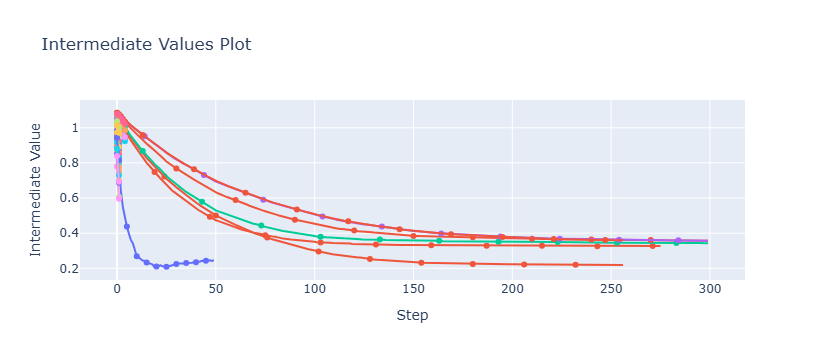

In [85]:
from optuna.visualization import plot_intermediate_values

# 1. Plot intermediate values during the trials
plot_intermediate_values(study).show()